# NOAA Workflow - rain_advanced
Download and inspect NOAA GFS data for this map type.

In [ ]:
from datetime import date
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(ROOT / 'scripts'))

from noaa_map_pipeline import download_map_dataset, analyze_data_folder, MAP_SPECS

MAP_TYPE = 'rain_advanced'
RUN_DATE = date(2026, 4, 6)
RUN_HOUR = 0
BASE_DIR = str(ROOT)

MAP_SPECS[MAP_TYPE]

MapSpec(map_type='rain_advanced', description='PRATE+CRAIN+CSNOW at surface, 24h every 3h', products=[Product(name='rain_adv_surface', query={'lev_surface': 'on', 'var_PRATE': 'on', 'var_CRAIN': 'on', 'var_CSNOW': 'on'})], fff_segments_full=[(0, 24, 3)])

In [ ]:
manifest = download_map_dataset(
    map_type=MAP_TYPE,
    run_date=RUN_DATE,
    run_hour=RUN_HOUR,
    base_dir=BASE_DIR,
    mode='available_only',  # use discovered timeline, not only f000
    rpm_limit=100,
)
summary = analyze_data_folder(BASE_DIR, MAP_TYPE)
print('Downloads:', len(manifest['downloads']))
print('FFF source:', manifest.get('fff_source'))
print('FFF count:', len(manifest.get('fff_values_requested', [])))
print('First 20 FFF:', manifest.get('fff_values_requested', [])[:20])
print(json.dumps(summary, indent=2)[:1500])

Download rain_advanced: 1/1 (100.00%) | ETA 00:00 | fff=000 product=rain_adv_surface status=skipped_existing
Downloads: 1
{
  "map_type": "rain_advanced",
  "file_count": 209,
  "total_size_mb": 307.807,
  "fff_available": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
    96,
    97,
 

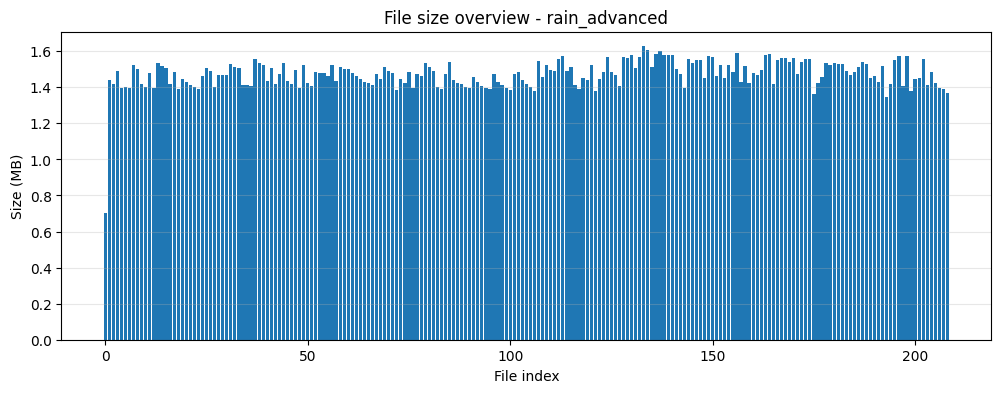

In [4]:
try:
    import matplotlib.pyplot as plt
    files = summary['files']
    names = [f['file'] for f in files]
    sizes_mb = [round(f['size_bytes'] / (1024 * 1024), 3) for f in files]

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(names)), sizes_mb)
    plt.title(f'File size overview - {MAP_TYPE}')
    plt.xlabel('File index')
    plt.ylabel('Size (MB)')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
except Exception as exc:
    print('Matplotlib plot skipped:', exc)

In [8]:
from pathlib import Path
import re

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import xarray as xr

ROOT = Path.cwd().resolve().parents[1]
map_type = globals().get("MAP_TYPE", "rain_advanced")
data_dir = ROOT / "data" / map_type


def _read_var_from_grib(file_path: Path, short_name: str):
    try:
        ds = xr.open_dataset(
            file_path,
            engine="cfgrib",
            backend_kwargs={"filter_by_keys": {"shortName": short_name}},
        )
    except Exception:
        return None

    try:
        if not ds.data_vars:
            return None

        var_name = list(ds.data_vars)[0]
        lat_name = "latitude" if "latitude" in ds.coords else "lat"
        lon_name = "longitude" if "longitude" in ds.coords else "lon"
        z = np.squeeze(ds[var_name].values)
        lat = ds[lat_name].values
        lon = ds[lon_name].values

        if z.ndim != 2:
            return None
        return lon, lat, z
    finally:
        ds.close()


def _parse_fff(name: str):
    m = re.search(r"\.f(\d{3})\.", name)
    return int(m.group(1)) if m else None


files = sorted(data_dir.glob("*.grib2"))
frames = []

for fp in files:
    fff = _parse_fff(fp.name)
    if fff is None:
        continue

    prate_data = _read_var_from_grib(fp, "prate")
    crain_data = _read_var_from_grib(fp, "crain")
    csnow_data = _read_var_from_grib(fp, "csnow")

    if prate_data is None:
        continue

    lon, lat, prate = prate_data
    if crain_data is None:
        crain = np.zeros_like(prate)
    else:
        _, _, crain = crain_data

    if csnow_data is None:
        csnow = np.zeros_like(prate)
    else:
        _, _, csnow = csnow_data

    frames.append(
        {
            "fff": fff,
            "lon": lon,
            "lat": lat,
            "prate": prate,
            "crain": crain,
            "csnow": csnow,
        }
    )

frames = sorted(frames, key=lambda x: x["fff"])
print(f"Loaded {len(frames)} time frame(s) from {data_dir}")

if len(frames) <= 1:
    print("Warning: only one frame available. Run Cell 3 with mode='available_only' and ensure full data is downloaded.")
if not frames:
    raise ValueError("No valid rain_advanced frames were loaded.")

step = 4
for fr in frames:
    fr["lon"] = fr["lon"][::step]
    fr["lat"] = fr["lat"][::step]
    fr["prate"] = fr["prate"][::step, ::step]
    fr["crain"] = fr["crain"][::step, ::step]
    fr["csnow"] = fr["csnow"][::step, ::step]

prate_all = np.stack([f["prate"] for f in frames])
crain_all = np.stack([f["crain"] for f in frames])
csnow_all = np.stack([f["csnow"] for f in frames])

# Convert PRATE from kg m^-2 s^-1 to mm/hour for intuitive thresholds.
prate_mm_h = prate_all * 3600.0
prate_max = float(np.nanmax(prate_mm_h)) if np.isfinite(prate_mm_h).any() else 1.0
if prate_max <= 0:
    prate_max = 1.0

combined_all = (prate_mm_h / prate_max) * (1.0 + 0.8 * crain_all + 0.8 * csnow_all)

# Effect layer categories:
# 0 no precip, 1 light rain, 2 heavy rain, 3 light snow, 4 heavy snow, 5 mixed rain/snow
rain_mask = crain_all > 0.1
snow_mask = csnow_all > 0.1
mixed_mask = rain_mask & snow_mask
rain_only = rain_mask & (~snow_mask)
snow_only = snow_mask & (~rain_mask)

light_mask = prate_mm_h < 1.5

effect_all = np.zeros_like(prate_mm_h, dtype=np.int32)
effect_all[rain_only & light_mask] = 1
effect_all[rain_only & (~light_mask)] = 2
effect_all[snow_only & light_mask] = 3
effect_all[snow_only & (~light_mask)] = 4
effect_all[mixed_mask] = 5

first = frames[0]

fig = make_subplots(
    rows=1,
    cols=5,
    subplot_titles=["PRATE (mm/h)", "CRAIN", "CSNOW", "Combined Index", "Effect Layer"],
    horizontal_spacing=0.03,
)

fig.add_trace(
    go.Heatmap(
        z=prate_mm_h[0],
        x=first["lon"],
        y=first["lat"],
        colorscale="Blues",
        zmin=float(np.nanmin(prate_mm_h)),
        zmax=float(np.nanmax(prate_mm_h)),
        colorbar={"title": "PRATE", "x": 0.16},
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Heatmap(
        z=first["crain"],
        x=first["lon"],
        y=first["lat"],
        colorscale="YlGn",
        zmin=float(np.nanmin(crain_all)),
        zmax=float(np.nanmax(crain_all)),
        colorbar={"title": "CRAIN", "x": 0.34},
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Heatmap(
        z=first["csnow"],
        x=first["lon"],
        y=first["lat"],
        colorscale="PuBu",
        zmin=float(np.nanmin(csnow_all)),
        zmax=float(np.nanmax(csnow_all)),
        colorbar={"title": "CSNOW", "x": 0.52},
    ),
    row=1,
    col=3,
)
fig.add_trace(
    go.Heatmap(
        z=combined_all[0],
        x=first["lon"],
        y=first["lat"],
        colorscale="Turbo",
        zmin=float(np.nanmin(combined_all)),
        zmax=float(np.nanmax(combined_all)),
        colorbar={"title": "Combined", "x": 0.70},
    ),
    row=1,
    col=4,
)

# Discrete color map for effect classes.
effect_scale = [
    [0.00, "#f5f5f5"],
    [0.20, "#9ecae1"],
    [0.40, "#08519c"],
    [0.60, "#c7e9c0"],
    [0.80, "#006d2c"],
    [1.00, "#7a0177"],
]
fig.add_trace(
    go.Heatmap(
        z=effect_all[0],
        x=first["lon"],
        y=first["lat"],
        colorscale=effect_scale,
        zmin=0,
        zmax=5,
        colorbar={
            "title": "Effect",
            "x": 0.97,
            "tickmode": "array",
            "tickvals": [0, 1, 2, 3, 4, 5],
            "ticktext": [
                "No precip",
                "Light rain",
                "Heavy rain",
                "Light snow",
                "Heavy snow",
                "Mixed",
            ],
        },
    ),
    row=1,
    col=5,
)

plotly_frames = []
steps = []
for idx, fr in enumerate(frames):
    name = f"fff_{fr['fff']:03d}"
    plotly_frames.append(
        go.Frame(
            name=name,
            data=[
                go.Heatmap(z=prate_mm_h[idx], x=fr["lon"], y=fr["lat"]),
                go.Heatmap(z=fr["crain"], x=fr["lon"], y=fr["lat"]),
                go.Heatmap(z=fr["csnow"], x=fr["lon"], y=fr["lat"]),
                go.Heatmap(z=combined_all[idx], x=fr["lon"], y=fr["lat"]),
                go.Heatmap(z=effect_all[idx], x=fr["lon"], y=fr["lat"]),
            ],
            layout=go.Layout(title=f"Rain Advanced layers | f{fr['fff']:03d}"),
        )
    )
    steps.append(
        {
            "label": f"f{fr['fff']:03d}",
            "method": "animate",
            "args": [[name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}],
        }
    )

fig.frames = plotly_frames
fig.update_layout(
    title=f"Rain Advanced layers | f{first['fff']:03d}",
    height=660,
    width=2200,
    sliders=[
        {
            "currentvalue": {"prefix": "Forecast hour: "},
            "pad": {"t": 40},
            "steps": steps,
        }
    ],
    updatemenus=[
        {
            "type": "buttons",
            "showactive": False,
            "x": 0.0,
            "y": 1.16,
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [None, {"frame": {"duration": 350, "redraw": True}, "fromcurrent": True}],
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [[None], {"mode": "immediate", "frame": {"duration": 0, "redraw": False}}],
                },
            ],
        }
    ],
)

# Prefer rendering inside notebook output; fallback to browser if notebook renderer is unavailable.
try:
    fig.show()
except Exception:
    fig.show(renderer="browser")

print("Rendered rain_advanced timeline with PRATE + CRAIN + CSNOW + effect layer.")

Loaded 1 time frame(s) from D:\Work\Learn\HK6_2025-2026\flutter\Search_Wheather_forecast\data\rain_advanced


Rendered rain_advanced timeline with PRATE + CRAIN + CSNOW + effect layer.
